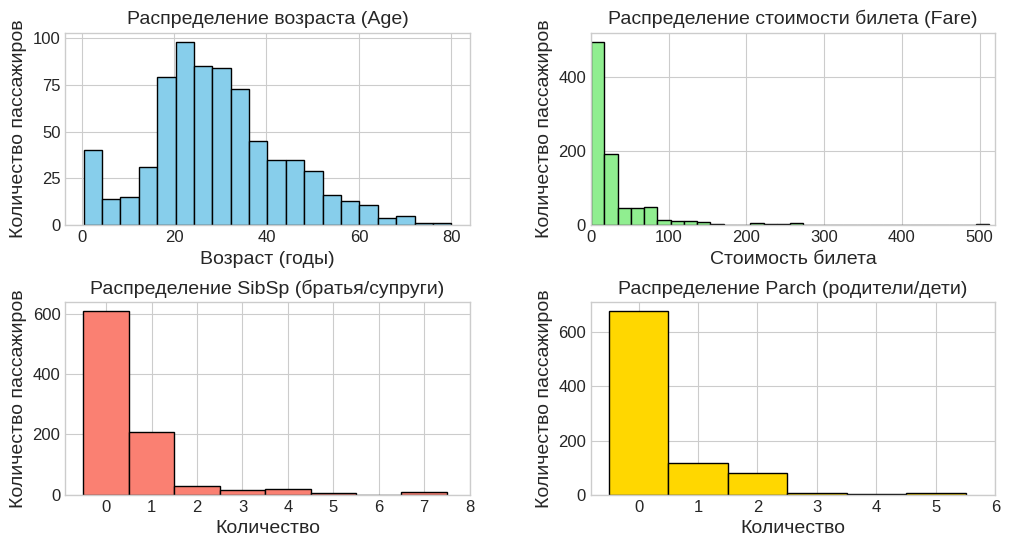

In [ ]:
#1.2.1. Диаграммы распределения признаков
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Titanic-Dataset.csv')

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(12, 6),
                         gridspec_kw={'hspace': 0.4, 'wspace': 0.3})

df['Age'].dropna().hist(bins=20, ax=axes[0, 0], color='skyblue', edgecolor='black', linewidth=1)
axes[0, 0].set_title('Распределение возраста (Age)', fontsize=14)
axes[0, 0].set_xlabel('Возраст (годы)', fontsize=14)
axes[0, 0].set_ylabel('Количество пассажиров', fontsize=14)
axes[0, 0].tick_params(axis='both', labelsize=12)

df['Fare'].hist(bins=30, ax=axes[0, 1], color='lightgreen', edgecolor='black', linewidth=1)
axes[0, 1].set_title('Распределение стоимости билета (Fare)', fontsize=14)
axes[0, 1].set_xlabel('Стоимость билета', fontsize=14)
axes[0, 1].set_ylabel('Количество пассажиров', fontsize=14)
axes[0, 1].set_xlim(0, 520)
axes[0, 1].tick_params(axis='both', labelsize=12)

df['SibSp'].hist(bins=range(9), ax=axes[1, 0], color='salmon', edgecolor='black', align='left', linewidth=1)
axes[1, 0].set_title('Распределение SibSp (братья/супруги)', fontsize=14)
axes[1, 0].set_xlabel('Количество', fontsize=14)
axes[1, 0].set_ylabel('Количество пассажиров', fontsize=14)
axes[1, 0].set_xticks(range(9))
axes[1, 0].tick_params(axis='both', labelsize=12)

df['Parch'].hist(bins=range(7), ax=axes[1, 1], color='gold', edgecolor='black', align='left', linewidth=1)
axes[1, 1].set_title('Распределение Parch (родители/дети)', fontsize=14)
axes[1, 1].set_xlabel('Количество', fontsize=14)
axes[1, 1].set_ylabel('Количество пассажиров', fontsize=14)
axes[1, 1].set_xticks(range(7))
axes[1, 1].tick_params(axis='both', labelsize=12)

plt.show()

In [ ]:
df.info()

NameError: name 'df' is not defined

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


/tmp/ipykernel_8191/1811183478.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sex', y='Age', ax=axes[0], palette='pastel')
/tmp/ipykernel_8191/1811183478.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Мужской', 'Женский'], fontsize=16)
/tmp/ipykernel_8191/1811183478.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Pclass', y='Fare', ax=axes[1], palette='muted')
/tmp/ipykernel_8191/1811183478.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and s

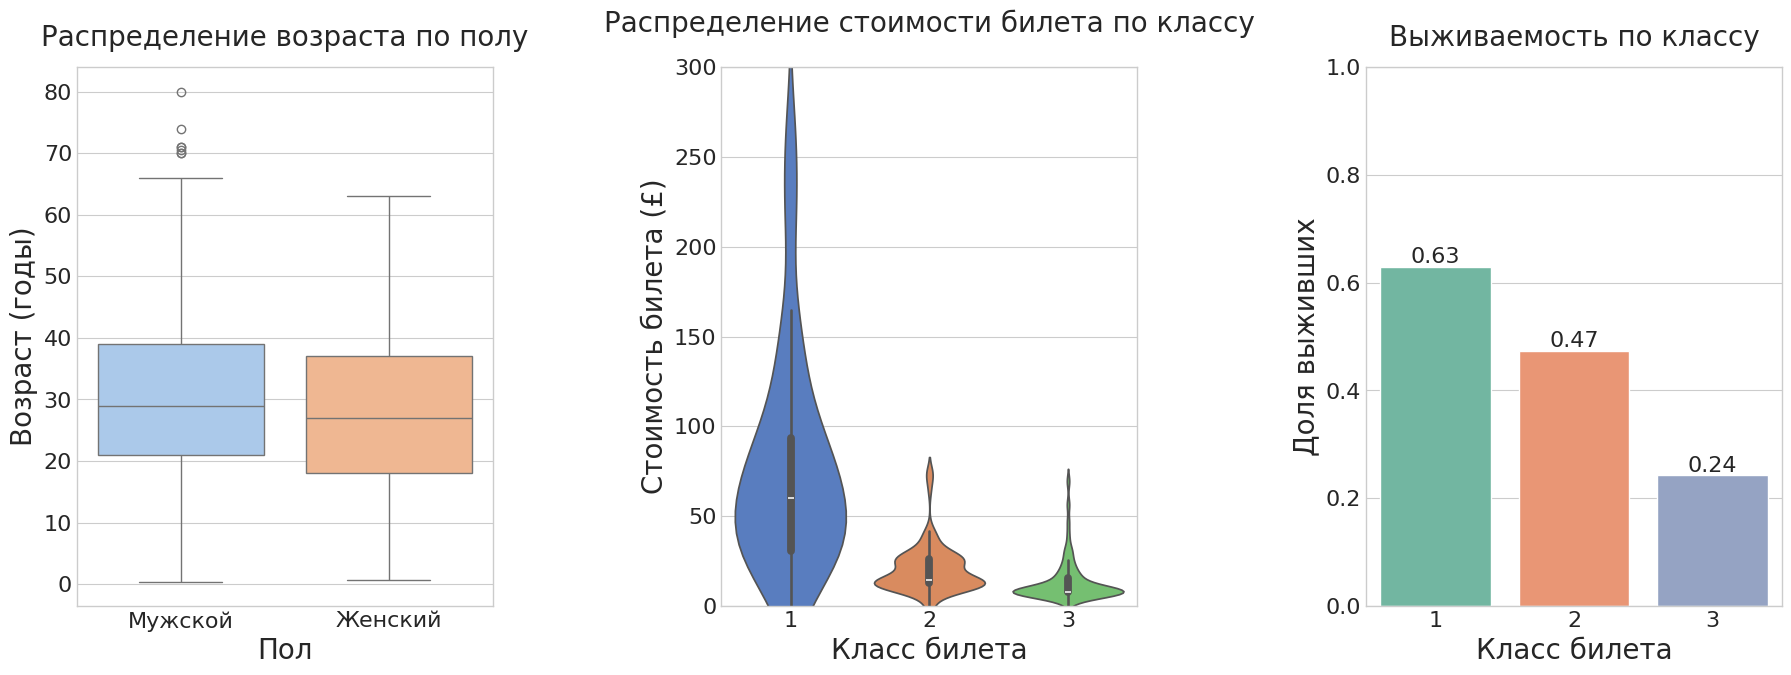

In [ ]:
#1.2.2. Визуализация признаков средствами библиотеки Seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Titanic-Dataset.csv')

sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(22, 7), gridspec_kw={'wspace': 0.55})

sns.boxplot(data=df, x='Sex', y='Age', ax=axes[0], palette='pastel')
axes[0].set_title('Распределение возраста по полу', fontsize=20, pad=15)
axes[0].set_xlabel('Пол', fontsize=20)
axes[0].set_ylabel('Возраст (годы)', fontsize=20)
axes[0].set_xticklabels(['Мужской', 'Женский'], fontsize=16)
axes[0].tick_params(axis='both', labelsize=16)

sns.violinplot(data=df, x='Pclass', y='Fare', ax=axes[1], palette='muted')
axes[1].set_title('Распределение стоимости билета по классу', fontsize=20, pad=25)
axes[1].set_xlabel('Класс билета', fontsize=20)
axes[1].set_ylabel('Стоимость билета (£)', fontsize=20)
axes[1].tick_params(axis='both', labelsize=16)
axes[1].set_ylim(0, 300)

survival_by_class = df.groupby('Pclass')['Survived'].mean().reset_index()
sns.barplot(data=survival_by_class, x='Pclass', y='Survived', ax=axes[2], palette='Set2')
axes[2].set_title('Выживаемость по классу', fontsize=20, pad=15)
axes[2].set_xlabel('Класс билета', fontsize=20)
axes[2].set_ylabel('Доля выживших', fontsize=20)
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='both', labelsize=16)
for i, p in enumerate(axes[2].patches):
    axes[2].annotate(f'{survival_by_class["Survived"].iloc[i]:.2f}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
#1.2.3.	Визуализация признаков библиотекой plotly
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('Titanic-Dataset.csv')
df_clean = df.dropna(subset=['Age'])

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Распределение возраста пассажиров',
                    'Зависимость стоимости билета от возраста'),
    horizontal_spacing=0.18
)

fig.add_trace(
    go.Histogram(
        x=df_clean['Age'],
        nbinsx=20,
        marker=dict(color='skyblue', line=dict(color='black', width=1.5)),
        name='Возраст'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=df_clean['Age'],
        y=df_clean['Fare'],
        mode='markers',
        marker=dict(color='green', opacity=0.6, size=8),
        name='Пассажиры'
    ),
    row=1, col=2
)

fig.update_xaxes(title_text='Возраст (годы)',
                 title_font=dict(size=20),
                 tickfont=dict(size=20),
                 row=1, col=1)
fig.update_yaxes(title_text='Количество пассажиров',
                 title_font=dict(size=20),
                 tickfont=dict(size=20),
                 row=1, col=1)

fig.update_xaxes(title_text='Возраст (годы)',
                 title_font=dict(size=20),
                 tickfont=dict(size=20),
                 row=1, col=2)
fig.update_yaxes(title_text='Стоимость билета (£)',
                 range=[0, 300],
                 title_font=dict(size=20),
                 tickfont=dict(size=20),
                 row=1, col=2)

fig.update_annotations(y=1.1,
                       font=dict(size=20))

fig.update_layout(
    width=1000,
    height=500,
    margin=dict(t=130),
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=14)
)

fig.show()
fig.write_html('figure3_font23.html')

In [ ]:
#1.2.4. Обработка строк с нулевыми значениями
import pandas as pd
from google.colab import files

df = pd.read_csv('Titanic-Dataset.csv')

mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked, inplace=True)

median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)

df.drop('Cabin', axis=1, inplace=True)

print(df.isnull().sum())

df.to_csv('Titanic_processed.csv', index=False)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_4947/3444876811.py:10: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_4947/3444876811.py:14: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' 

/tmp/ipykernel_2888/820319580.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  numeric_df['Age'].fillna(df['Age'].median(), inplace=True)


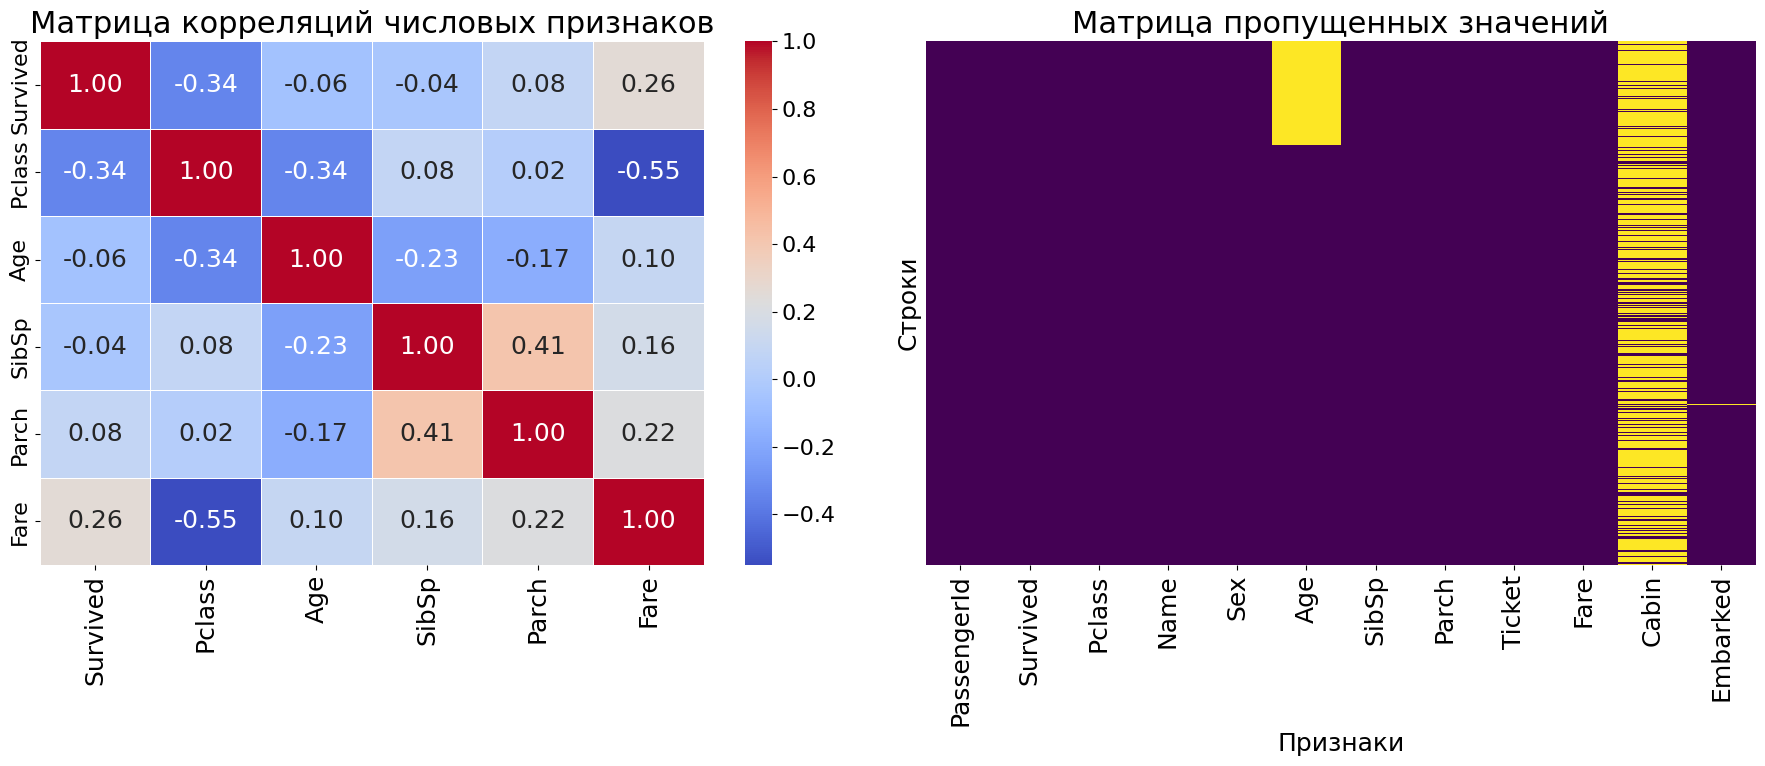

In [ ]:
#1.2.5. Построение тепловой карты
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 18})
plt.rcParams.update({'axes.titlesize': 22})
plt.rcParams.update({'axes.labelsize': 18})
plt.rcParams.update({'xtick.labelsize': 18})
plt.rcParams.update({'ytick.labelsize': 16})

df = pd.read_csv('Titanic-Dataset.csv')

numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
numeric_df['Age'].fillna(df['Age'].median(), inplace=True)

df_sorted = df.sort_values(by='Age', key=lambda x: x.isnull(), ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, cbar=True, ax=ax1,
            annot_kws={'size': 18})
ax1.set_title('Матрица корреляций числовых признаков')
ax1.tick_params(axis='y', labelsize=16)
ax1.tick_params(axis='x', labelsize=18)

sns.heatmap(df_sorted.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax2)
ax2.set_title('Матрица пропущенных значений')
ax2.set_xlabel('Признаки')
ax2.set_ylabel('Строки')
ax2.tick_params(axis='x', labelsize=18)

plt.tight_layout()
plt.show()

In [ ]:
#1.2.6. Устранение дубликатов строк
import pandas as pd

df = pd.read_csv('Titanic-Dataset.csv')

print(f"Файл загружен. Количество строк: {len(df)}")
print(f"Столбцы: {df.columns.tolist()}")

duplicates_mask = df.duplicated(keep=False)
duplicate_rows = df[duplicates_mask]

num_duplicates = df.duplicated().sum()

print(f"\nКоличество полностью дублирующихся строк (вторые, третьи и т.д. вхождения): {num_duplicates}")
print(f"Всего строк, участвующих в дубликатах (включая первые): {len(duplicate_rows)}")

if len(duplicate_rows) > 0:
    print("\nВсе дублирующиеся строки (с именами):")
    duplicate_rows_sorted = duplicate_rows.sort_values(by=list(df.columns))
    if 'Name' in duplicate_rows_sorted.columns:
        cols = ['Name'] + [c for c in duplicate_rows_sorted.columns if c != 'Name']
        print(duplicate_rows_sorted[cols].to_string())
    else:
        print(duplicate_rows_sorted.to_string())
else:
    print("Полных дубликатов строк (по всем столбцам) не найдено.")

Файл загружен. Количество строк: 891
Столбцы: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Количество полностью дублирующихся строк (вторые, третьи и т.д. вхождения): 0
Всего строк, участвующих в дубликатах (включая первые): 0
Полных дубликатов строк (по всем столбцам) не найдено.


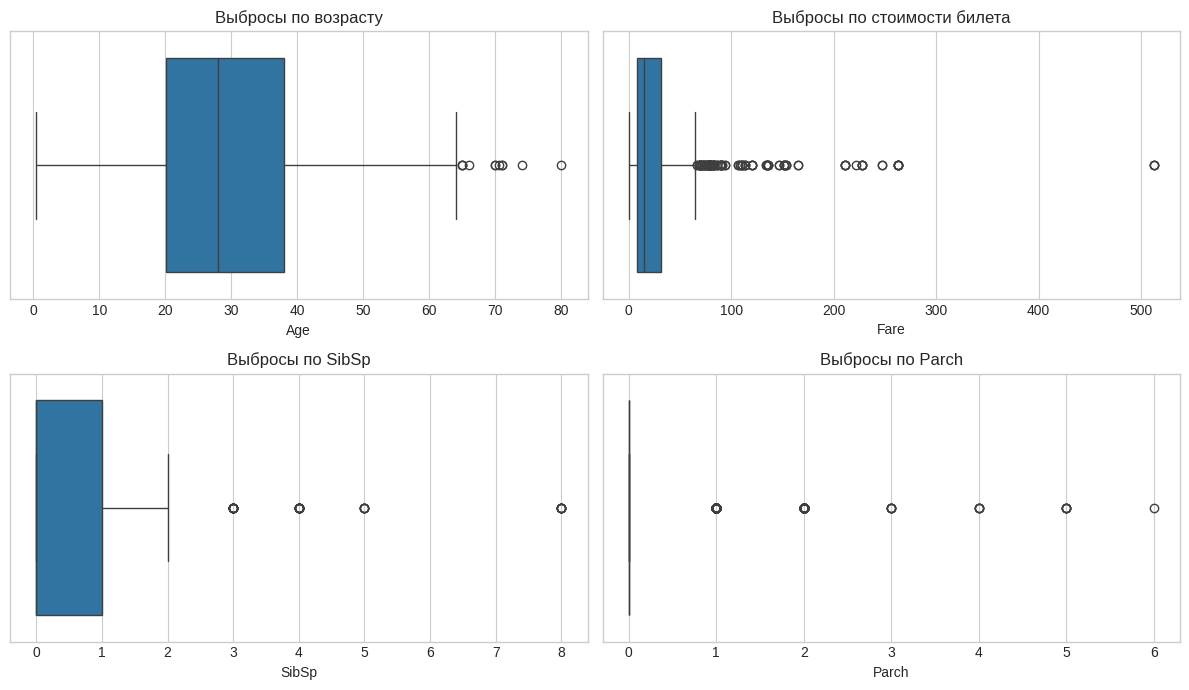

In [ ]:
#1.2.7.	Появление нетипичных выбросов по признакам
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Titanic-Dataset.csv')

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

sns.boxplot(data=df, x='Age', ax=axes[0,0])
axes[0,0].set_title('Выбросы по возрасту')

sns.boxplot(data=df, x='Fare', ax=axes[0,1])
axes[0,1].set_title('Выбросы по стоимости билета')

sns.boxplot(data=df, x='SibSp', ax=axes[1,0])
axes[1,0].set_title('Выбросы по SibSp')

sns.boxplot(data=df, x='Parch', ax=axes[1,1])
axes[1,1].set_title('Выбросы по Parch')

plt.tight_layout()
plt.show()

In [ ]:
#1.2.8.	Условная фильтрация сэмплов
import pandas as pd

df = pd.read_csv('Titanic-Dataset.csv')

first_class = df[df['Pclass'] == 1]
print(f"Пассажиров первого класса: {len(first_class)}")

women_with_children = df[(df['Sex'] == 'female') & (df['Survived'] == 1) & (df['Parch'] > 0)]
print(f"Выживших женщин, имевших детей на борту: {len(women_with_children)}")

third_class_expensive = df[(df['Pclass'] == 3) & (df['Fare'] > 50)]
print(f"Пассажиров третьего класса с билетом дороже 50: {len(third_class_expensive)}")

Пассажиров первого класса: 216
Выживших женщин, имевших детей на борту: 80
Пассажиров третьего класса с билетом дороже 50: 14


In [ ]:
#1.2.9.Добавление шума
import pandas as pd
import numpy as np

df = pd.read_csv('Titanic-Dataset.csv')

median_age = df['Age'].median()
df['Age_clean'] = df['Age'].fillna(median_age)

age_std = df['Age_clean'].std()
fare_std = df['Fare'].std()

np.random.seed(42)
noise_age = np.random.normal(0, 0.05 * age_std, len(df))
noise_fare = np.random.normal(0, 0.05 * fare_std, len(df))

df['Age_noisy'] = df['Age_clean'] + noise_age
df['Fare_noisy'] = df['Fare'] + noise_fare

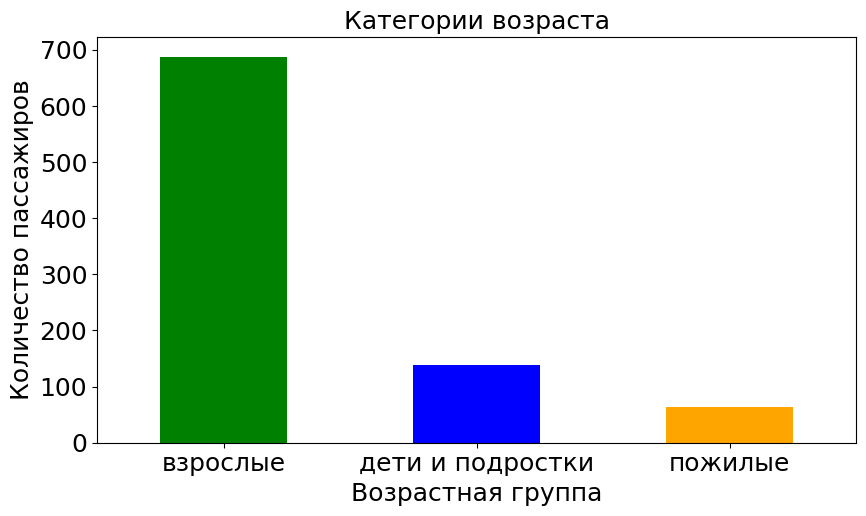

In [ ]:
#1.2.10. Преобразование числовых данных в категориальные
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Titanic-Dataset.csv')

median_age = df['Age'].median()
df['Age_filled'] = df['Age'].fillna(median_age)

def age_to_category(age):
    if age <= 18:
        return 'дети и подростки'
    elif age <= 50:
        return 'взрослые'
    else:
        return 'пожилые'

df['Age_category'] = df['Age_filled'].apply(age_to_category)

plt.figure(figsize=(9, 5.5))
ax = df['Age_category'].value_counts().plot(kind='bar', color=['green', 'blue', 'orange'])

ax.set_title('Категории возраста', fontsize=18)
ax.set_xlabel('Возрастная группа', fontsize=18)
ax.set_ylabel('Количество пассажиров', fontsize=18)
ax.tick_params(axis='both', labelsize=18)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=18)

plt.tight_layout()
plt.show()

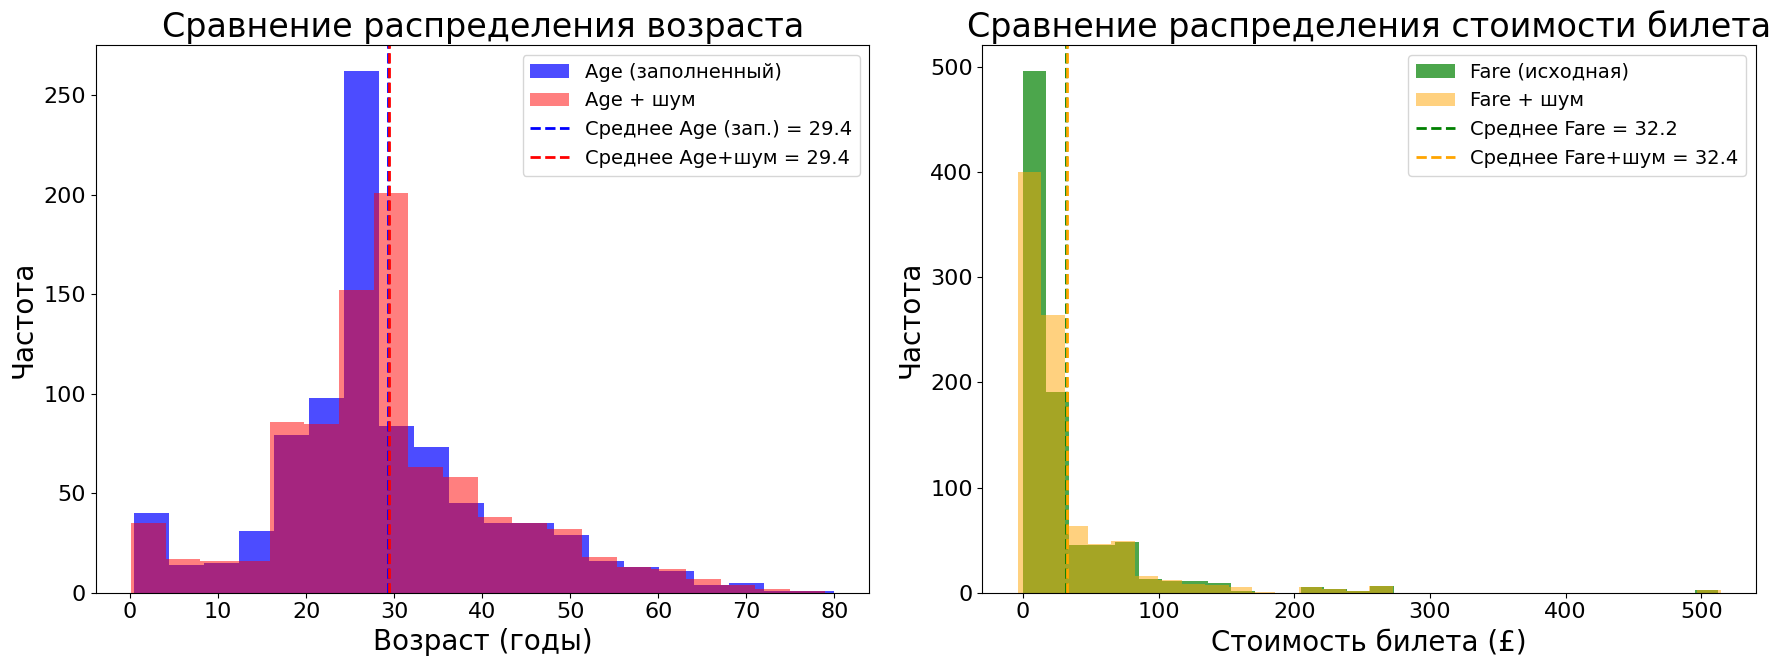

In [ ]:
#1.2.12. Оценка изменения данных после фильтрации
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Titanic-Dataset.csv')

median_age = df['Age'].median()
df['Age_filled'] = df['Age'].fillna(median_age)

np.random.seed(42)
age_std = df['Age_filled'].std()
fare_std = df['Fare'].std()

df['Age_noisy'] = df['Age_filled'] + np.random.normal(0, 0.05 * age_std, len(df))
df['Fare_noisy'] = df['Fare'] + np.random.normal(0, 0.05 * fare_std, len(df))

bins = [0, 18, 50, 100]
labels = ['child_teen', 'adult', 'senior']
df['age_group'] = pd.cut(df['Age_filled'], bins=bins, labels=labels, right=False)

mean_age_filled = df['Age_filled'].mean()
mean_age_noisy = df['Age_noisy'].mean()
mean_fare = df['Fare'].mean()
mean_fare_noisy = df['Fare_noisy'].mean()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].hist(df['Age_filled'], bins=20, alpha=0.7, label='Age (заполненный)', color='blue')
axes[0].hist(df['Age_noisy'], bins=20, alpha=0.5, label='Age + шум', color='red')
axes[0].axvline(mean_age_filled, color='blue', linestyle='dashed', linewidth=2,
                label=f'Среднее Age (зап.) = {mean_age_filled:.1f}')
axes[0].axvline(mean_age_noisy, color='red', linestyle='dashed', linewidth=2,
                label=f'Среднее Age+шум = {mean_age_noisy:.1f}')
axes[0].set_xlabel('Возраст (годы)', fontsize=20)
axes[0].set_ylabel('Частота', fontsize=20)
axes[0].set_title('Сравнение распределения возраста', fontsize=24)
axes[0].legend(fontsize=14)
axes[0].tick_params(axis='both', labelsize=16)

axes[1].hist(df['Fare'], bins=30, alpha=0.7, label='Fare (исходная)', color='green')
axes[1].hist(df['Fare_noisy'], bins=30, alpha=0.5, label='Fare + шум', color='orange')
axes[1].axvline(mean_fare, color='green', linestyle='dashed', linewidth=2,
                label=f'Среднее Fare = {mean_fare:.1f}')
axes[1].axvline(mean_fare_noisy, color='orange', linestyle='dashed', linewidth=2,
                label=f'Среднее Fare+шум = {mean_fare_noisy:.1f}')
axes[1].set_xlabel('Стоимость билета (£)', fontsize=20)
axes[1].set_ylabel('Частота', fontsize=20)
axes[1].set_title('Сравнение распределения стоимости билета', fontsize=24)
axes[1].legend(fontsize=14)
axes[1].tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.show()

/tmp/ipykernel_8191/3130707307.py:6: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





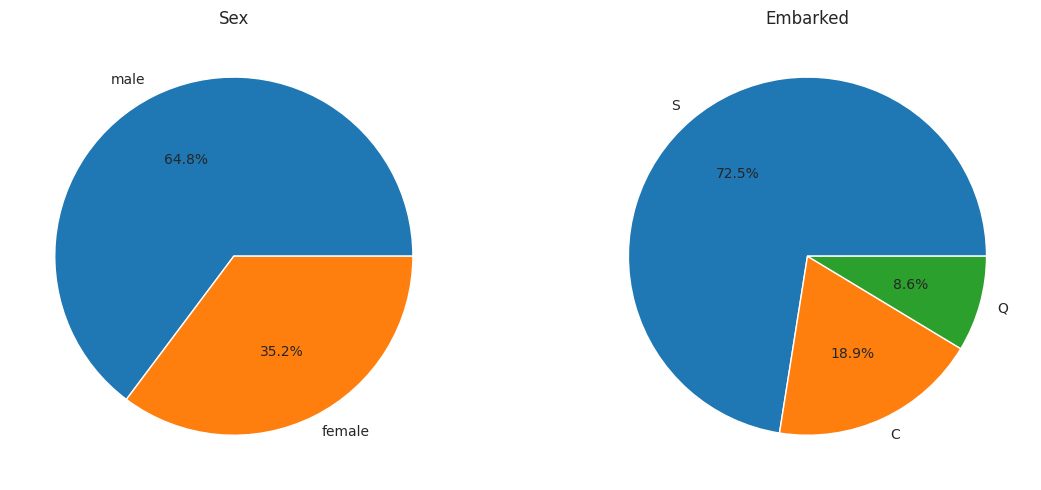

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Titanic-Dataset.csv')

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Sex'].value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%')
axes[0].set_title('Sex')
axes[0].set_ylabel('')

df['Embarked'].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Embarked')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
#1.3.3.Преобразование категориальных данных в числовые
import pandas as pd

df = pd.read_csv('Titanic-Dataset.csv')

df['Sex_binary'] = df['Sex'].map({'male': 0, 'female': 1})

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked', dtype=int)

print(df[['Sex_binary', 'Embarked_C', 'Embarked_Q', 'Embarked_S']].head())

   Sex_binary  Embarked_C  Embarked_Q  Embarked_S
0           0           0           0           1
1           1           1           0           0
2           1           0           0           1
3           1           0           0           1
4           0           0           0           1


/tmp/ipykernel_8191/2840818725.py:9: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
#1.3.4.Агрегация данных
import pandas as pd

df = pd.read_csv('Titanic-Dataset.csv')

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

categorical_cols = ['Sex', 'Pclass', 'Embarked']

print("=== Анализ редких категорий (порог < 5%) ===\n")
total_rows = len(df)
threshold = 0.05 * total_rows

for col in categorical_cols:
    print(f"Признак: {col}")
    freq = df[col].value_counts()
    rare = freq[freq < threshold]
    if not rare.empty:
        print(f"  Редкие категории (встречаемость < {threshold:.0f}):")
        for cat, count in rare.items():
            print(f"    {cat}: {count} записей ({count/total_rows*100:.1f}%)")
    else:
        print("  Редких категорий не обнаружено.")
    print()

=== Анализ редких категорий (порог < 5%) ===

Признак: Sex
  Редких категорий не обнаружено.

Признак: Pclass
  Редких категорий не обнаружено.

Признак: Embarked
  Редких категорий не обнаружено.



/tmp/ipykernel_8191/1117514375.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


/tmp/ipykernel_8191/3751882602.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=['#3498db', '#e74c3c'])
/tmp/ipykernel_8191/3751882602.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Alone', y='Survived', data=surv_mean, palette=['#3498db', '#e74c3c'])


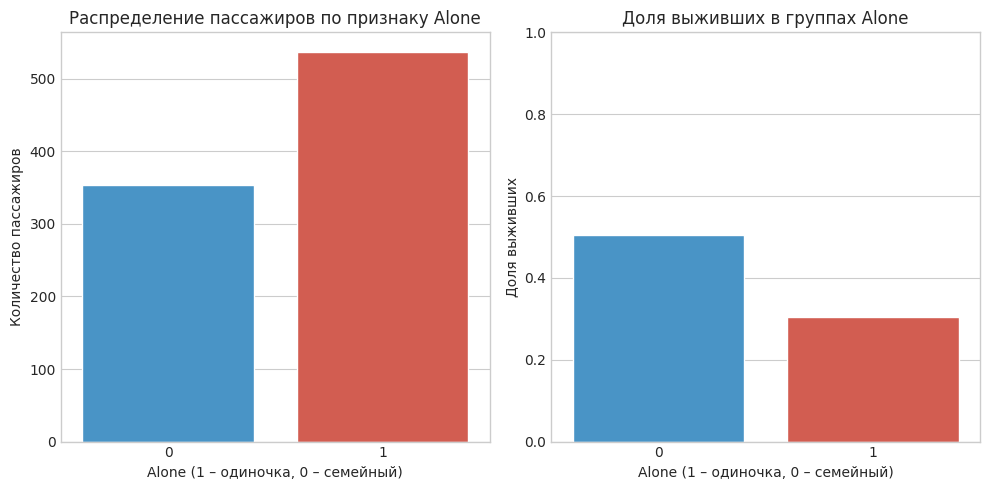

In [ ]:
#1.3.5. Введение новой категории
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Titanic-Dataset.csv')

df['Alone'] = ((df['SibSp'] == 0) & (df['Parch'] == 0)).astype(int)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

plt.subplot(1, 2, 1)
counts = df['Alone'].value_counts()
sns.barplot(x=counts.index, y=counts.values, palette=['#3498db', '#e74c3c'])
plt.title('Распределение пассажиров по признаку Alone')
plt.xlabel('Alone (1 – одиночка, 0 – семейный)')
plt.ylabel('Количество пассажиров')

plt.subplot(1, 2, 2)
surv_mean = df.groupby('Alone')['Survived'].mean().reset_index()
sns.barplot(x='Alone', y='Survived', data=surv_mean, palette=['#3498db', '#e74c3c'])
plt.ylim(0, 1)
plt.title('Доля выживших в группах Alone')
plt.xlabel('Alone (1 – одиночка, 0 – семейный)')
plt.ylabel('Доля выживших')

plt.tight_layout()
plt.show()